## Decision Trees


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [32]:
#1. Generate data
X, y = make_blobs(n_samples=500, centers=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [33]:
#init DT model

model = DecisionTreeClassifier(max_depth=5, random_state=42)

In [34]:
#fit the model to the training data

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [35]:
# make predictions

y_pred = model.predict(X_test)

In [36]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Scikit-learn Model Accuracy: {accuracy * 100:.2f}%")

Scikit-learn Model Accuracy: 100.00%


[Text(0.5, 0.75, 'x[0] <= 1.256\ngini = 0.5\nsamples = 100.0%\nvalue = [0.512, 0.488]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 51.2%\nvalue = [1.0, 0.0]'),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 48.8%\nvalue = [0.0, 1.0]')]

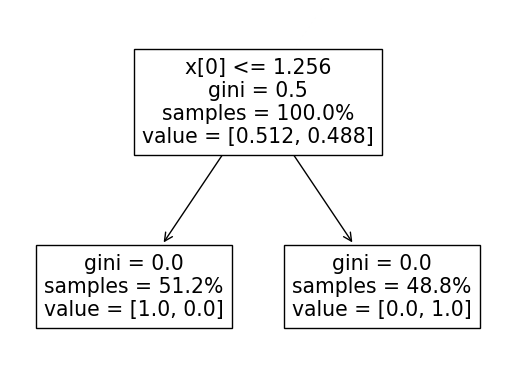

In [37]:
#visiuallize the tree

tree.plot_tree(model, proportion=True)

In [38]:
# Explore decision path for explainability

### Evaluation and Improvements

A. Evaluation Metrics
For a classification task, we use different metrics than for regression:

Accuracy: The most straightforward metric, measuring the percentage of correctly predicted instances.

Accuracy= (NumberofCorrectPredictions/TotalNumberofPredictions)

​
 
Precision: Of all the instances we predicted as positive, how many were actually positive? This is important when the cost of a false positive is high (e.g., a spam filter).

Precision= TruePositives/TruePositives+FalsePositives

​
 
Recall (Sensitivity): Of all the instances that were actually positive, how many did we correctly identify? This is important when the cost of a false negative is high (e.g., cancer detection).

Recall= 
TruePositives/TruePositives+FalseNegatives

​
 
F1-Score: The harmonic mean of Precision and Recall. It provides a single score that balances both metrics, which is useful when there's an uneven class distribution.

F1=2× (Precision×Recall/Precision+Recall)

​
 
ROC Curve and AUC: The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate (Recall) against the False Positive Rate at various threshold settings. The Area Under the Curve (AUC) measures the entire area underneath the ROC curve. A value of 1 indicates a perfect classifier, while 0.5 indicates a useless one. This is a very common metric for interviewers.

#### Improvements
B. Improving the Model: The Overfitting Problem
Decision Trees are notorious for overfitting because they can grow to be very deep and perfectly fit the training data's noise. The key to improving them is to prevent this.

Pruning: This is the process of removing sub-nodes of a decision tree. It can be done during or after the tree is built.

Pre-Pruning: Stop the tree's growth early. This is done by setting hyperparameters like max_depth, min_samples_split, and min_samples_leaf before training.

Post-Pruning: Allow the tree to grow to its full depth, then remove branches that don't contribute much to accuracy on a validation set. Scikit-learn doesn't directly support post-pruning, but it's a common concept to know.

Hyperparameter Tuning: You can use methods like Grid Search or Random Search to find the optimal values for the pruning hyperparameters.

Ensemble Methods: The most powerful way to improve Decision Trees is to use them as building blocks for more advanced models like Random Forests and XGBoost. These models combine multiple trees to reduce the high variance of a single tree, which we will cover next.

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Assuming y_test and y_pred from the scikit-learn example
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# You can also get a classification report that summarizes these metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# For AUC, you need the probabilities, not the final class predictions
y_probs = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_probs)
print(f"ROC AUC Score: {roc_auc:.2f}")

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        55

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

ROC AUC Score: 1.00
